# 03. Modeling — Day 1 전략대로 모델 개발 · 평가

**Task** : Classification (cycle_life ≥ 550 → Long=1 / Short=0), 지표 F1-Score · Accuracy
**모델링 방식** : log10(cycle_life) 회귀 → 예측 수명 550 기준 판정 (회귀는 분류를 위한 학습 수단)

### Day 1 보고서 → Day 2 구현 대응표

| Day 1 보고서 (모델 설계 전략) | Day 2 구현 | 위치 |
|---|---|---|
| 핵심 피처 ΔQ_100-10 분산, 보조 후보는 B1 CV 에서 개선될 때만 추가 | `core` 채택, 첨도·전환 시점 미채택 | 02-4 |
| 타깃 log10 변환, 중도 종료 셀 회귀 학습 제외 | `RegThreshold.fit` | src/train.py |
| 스케일러·결측 대체·하이퍼파라미터는 B1 으로만, 550 고정 | 파이프라인 + 내부 GroupKFold 튜닝 | src/train.py |
| Train = B1 충전 방식 단위 GroupKFold, Valid = 충전 방식 단위 20% Hold-out | `split_b1`, `cv_evaluate` | 1 |
| Test B2 : F1·Accuracy + Gap 3종, 보조로 AUC | 가이드 형식 표 | 2, 3 |
| B3 : MAPE·순위 상관 중심 해석 | Batch 3 형식 표 | 2 |
| 후보 5종 (ElasticNet / 단일 선형 / 로지스틱 / RandomForest / 전부 Long) | 동일 프로토콜 비교 | 4 |
| AUC 로 "순서는 맞고 기준이 어긋남" 원인 분리 | AUC·순위 상관 | 5 |
| 오분류가 B2 일반 셀에 몰리는지 오류 분석 | newstructure 별 집계 | 6 |
| B1 단독 선별 세트와 비교 (누수 점검) | `[B1 단독 선별]` | 7 |
| 5사이클 기준선으로 원논문과 같은 조건 비교 | `[5사이클 기준선]` | 8 |
| 소량 라벨 재보정 운영 시나리오 (본 성능과 분리) | k = 3 / 5 / 10 | 9 |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocess import ROOT, THRESHOLD
from src.train import run_all, TARGET_ACC, GROUP

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
FIG = ROOT / 'results' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
COLOR = {'B1': 'tab:blue', 'B2': 'tab:orange', 'B3': 'tab:green'}

o = run_all(save=True)          # 결과는 results/ 에 저장됨
perf = o['perf']
MAIN = 'ElasticNet → 550'
print('최종 피처 :', o['chosen'], '| ElasticNet 하이퍼파라미터 :', o['params'])

캐시 로드 : data/interim/cells.pkl


최종 피처 : ['w100_dQ_logvar'] | ElasticNet 하이퍼파라미터 : {'alpha': 0.001, 'l1_ratio': 0.1}


## 1. 데이터 분할

- **Train (B1 CV)** : B1 학습 구간에서 충전 방식 단위 5-fold GroupKFold 평균 → 같은 방식의 셀이 학습·검증에 나뉘면 성능이 부풀려지기 때문
- **Valid (B1 Hold-out)** : B1 의 충전 방식 약 20% 를 통째로 분리 → 셀 단위 분리를 보장하고, 배치 간 일반화를 보는 구조에 맞음 (가이드)
- **Test** : Hold-out 까지 포함한 **B1 전체로 다시 학습**한 모델로 B2(필수), B3(추가) 평가

In [2]:
for name, df in [('B1 학습 구간', o['b1_tr']), ('B1 Hold-out', o['b1_ho'])] + list(o['tests'].items()):
    print(f"{name:12s} : {len(df):3d}셀  Long {int(df.label.sum()):2d} / Short {int((df.label == 0).sum()):2d}  "
          f"중도 종료 {int(df.censored.sum())}  충전 방식 {df[GROUP].nunique()}종")
print('Hold-out 충전 방식 :', sorted(o['b1_ho'][GROUP].unique()))

B1 학습 구간     :  35셀  Long 34 / Short  1  중도 종료 7  충전 방식 18종
B1 Hold-out  :  11셀  Long 11 / Short  0  중도 종료 3  충전 방식 5종
B2           :  39셀  Long  9 / Short 30  중도 종료 0  충전 방식 9종
B3           :  40셀  Long 39 / Short  1  중도 종료 0  충전 방식 8종
Hold-out 충전 방식 : ['3.6C(80%)-3.6C', '5.4C(60%)-3C', '5.4C(70%)-3C', '6C(50%)-3C', '7C(30%)-3.6C']


## 2. 성능 결과 (가이드 Reporting format)

### Classification — 최종 모델 : ElasticNet (ΔQ_100-10 분산) → 550 판정

In [3]:
display(o['guide'].round(3))

,구분,F1-Score,Accuracy,비고
0,Train (Batch 1 CV),0.982,0.967,
1,Valid (Batch 1 Hold-out),1.000,1.000,
2,Test (Batch 2),0.450,0.436,
3,Gap (Train-Valid),-0.018,-0.033,(+) : 과적합 의심
4,Gap (Valid-Test),0.550,0.564,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),NaN,0.515,Target : Accuracy 95.1%


### Batch 3 (additional) — B2 결과와 나란히

In [4]:
display(o['guide_b3'].round(3))

,구분,F1-Score,Accuracy,비고
0,Train (Batch 1 CV),0.982,0.967,
1,Valid (Batch 1 Hold-out),1.000,1.000,
2,Test (Batch 2),0.450,0.436,
3,Gap (Train-Valid),-0.018,-0.033,(+) : 과적합 의심
4,Gap (Valid-Test),0.550,0.564,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),NaN,0.515,Target : Accuracy 95.1%
6,Test (Batch 3),0.987,0.975,Short 1개 → 수명 MAPE 11.9%·순위 상관 0.76 중심 해석
7,Gap (Batch2-Batch3),-0.537,-0.539,Test 성능 간 비교
8,"Gap (Target-Test, Batch 3)",NaN,-0.024,"Batch 3 기준, 원논문 성능 비교 (B3 정확도는 ""전부 Long"" 과 같은 ..."


### 보조 지표 (Day 1 보고서 5.3 : B1·B3 는 Short 가 1개 이하라 F1·Accuracy 만으로는 판단 불가)
- `macro_f1` : Long·Short 두 클래스 F1 평균 (Short 를 놓치면 크게 떨어짐) / `short_recall` : 실제 Short 중 맞힌 비율
- `mape` : 수명 예측 오차 (중도 종료 셀 제외) / `spearman` : 예측-실제 수명 순위 상관 / `auc` : 판정 기준과 무관한 순위 분리력

In [5]:
cols = ['split', 'n', 'n_short', 'f1', 'accuracy', 'macro_f1', 'short_recall', 'mape', 'spearman', 'auc', 'note']
display(perf[perf.model == MAIN][cols].round(3))

,split,n,n_short,f1,accuracy,macro_f1,short_recall,mape,spearman,auc,note
0,Train (B1 CV),7.0,0.2,0.982,0.967,0.491,0.000,7.666,0.671,0.8,
1,Valid (B1 Hold-out),11.0,0.0,1.000,1.000,0.500,NaN,11.148,0.333,NaN,
2,Test (B2),39.0,30.0,0.450,0.436,0.436,0.267,28.639,0.716,1.0,
3,Test (B3),40.0,1.0,0.987,0.975,0.494,0.000,11.917,0.765,1.0,


### 결과 해석 — Gap

| Gap | 값 (Accuracy) | 해석 |
|---|---|---|
| Train − Valid | −0.03 | 과적합 없음. 단, Hold-out 11셀에 Short 가 없어 Valid F1·Accuracy 는 1.0 이 될 수밖에 없음 → **Valid 의 실질 지표는 수명 오차 MAPE 11.1%** (CV 7.7% 와 비슷) |
| Valid − Test (B2) | +0.56 | **배치 간 일반화 저하** — Day 1 3장에서 예고한 결과 (B1 기준 적용 시 B2 정확도 0.26 → 모델 0.44) |
| Target − Test (B2) | +0.52 | 원논문 95.1% 대비 크게 낮음. 단 원논문은 5사이클 입력·B1+B2 혼합 학습으로 조건이 다름 (8 참고) |
| B2 − B3 | 정확도 −0.54 | B3 는 Short 1개라 정확도 0.975 = "전부 Long" 과 같음 → 판정 성능 근거 아님. **B3 수명 오차 11.9%** 로 B1 Hold-out(11.1%)과 비슷한 수준 유지 (Day 1 예상과 일치) |

**핵심** : B2 정확도는 낮지만 **AUC 는 1.0** → 모델이 Long/Short 의 **순서는 완벽히 맞히는데 550 기준의 위치만 어긋남** (5 에서 확인)

## 3. 예측 vs 실제 수명

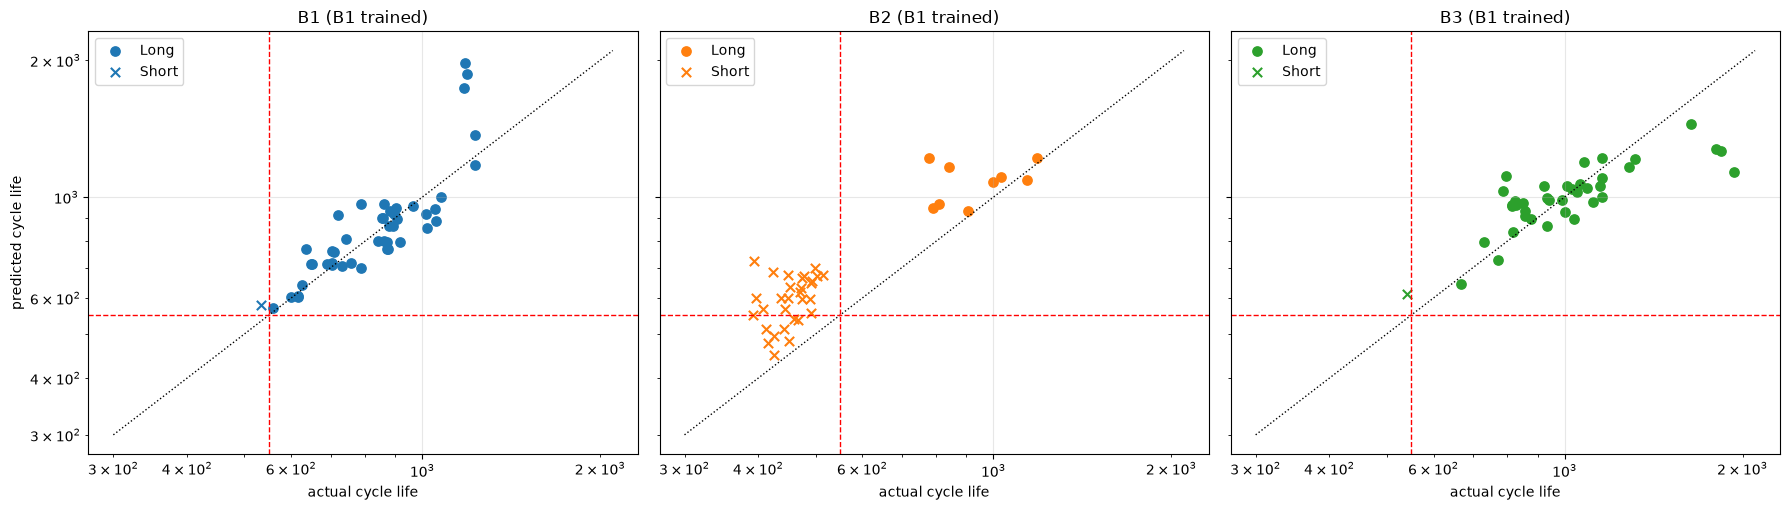

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharex=True, sharey=True)
final = o['finals'][MAIN]
for ax, b in zip(axes, ['B1', 'B2', 'B3']):
    df = o['feat'][o['feat'].batch == b]
    p = final.predict(df)
    for lab, mk in [(1, 'o'), (0, 'x')]:
        m = (df.label == lab).values
        ax.scatter(df.cycle_life[m], p['life'][m], marker=mk, s=45, color=COLOR[b], label='Long' if lab else 'Short')
    ax.plot([300, 2100], [300, 2100], 'k:', lw=1)
    ax.axhline(THRESHOLD, color='r', ls='--', lw=1); ax.axvline(THRESHOLD, color='r', ls='--', lw=1)
    ax.set(xscale='log', yscale='log', title=f'{b} (B1 trained)', xlabel='actual cycle life')
    ax.legend()
axes[0].set_ylabel('predicted cycle life')
plt.tight_layout(); plt.savefig(FIG / 'pred_vs_actual.png', dpi=120); plt.show()

- B1·B3 : 점이 대각선 근처 → B1 으로 배운 ΔQ–수명 관계가 B3 (학습 범위 밖 장수명 셀 포함)까지 유지됨
- B1 오른쪽 위 과대 예측 점들은 **중도 종료 셀** (실제 수명이 기록값 1200 보다 김) → 오차가 아니라 기록값이 하한값이기 때문 (MAPE 계산에서 제외)
- B2 : Short 셀(x)이 대각선 **위**에 몰림 → 수명을 일관되게 **과대 예측** (B2 일반 셀 예측/실제 중앙값 1.32배) → 550 선을 넘겨 Long 으로 오판
- B3 의 유일한 Short(541)도 611 로 예측되어 오판 → 그러나 B3 안에서 가장 짧게 예측된 셀임 (순서는 맞음)

## 4. 후보 모델 비교 (Day 1 보고서 [표 11])

In [7]:
show = perf.pivot_table(index='model', columns='split', values=['accuracy', 'macro_f1', 'mape'], sort=False)
order = ['Train (B1 CV)', 'Valid (B1 Hold-out)', 'Test (B2)', 'Test (B3)']
show = show.reindex(columns=pd.MultiIndex.from_product([['accuracy', 'macro_f1', 'mape'], order]))
display(show.round(3))
display(perf[perf.note != ''][['model', 'split', 'note']])

accuracy                                              macro_f1                                                  mape                                        
                            Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3)
model                                                                                                                                                                                        
ElasticNet → 550                    0.967                 1.0     0.436     0.975         0.491                 0.5     0.436     0.494         7.666              11.148    28.639    11.917
단일 피처 선형회귀 → 550                    0.967                 1.0     0.436     0.975         0.491                 0.5     0.436     0.494         7.603              11.186    28.594    11.925
로지스틱 회귀 (balanced)                  0.850                 1.0     0.821     0.975         0.457                 0.5     0.794     0.827           NaN                 NaN       NaN       NaN
RandomForest → 550                  0.967                 1.0     0.231     0.975         0.491                 0.5     0.188     0.494         9.156              11.326    32.336    15.807
전부 Long                             0.967                 1.0     0.231     0.975         0.491                 0.5     0.188     0.494           NaN                 NaN       NaN       NaN
ElasticNet → 550 [B1 단독 선별]         0.967                 1.0     0.385     0.975         0.491                 0.5     0.381     0.494        10.173              10.607    29.359    11.731
ElasticNet → 550 [5사이클 기준선]         0.967                 1.0     0.205     0.600         0.491                 0.5     0.170     0.427        19.619               9.491    64.730    39.547

,model,split,note
8,로지스틱 회귀 (balanced),Train (B1 CV),1개 fold 학습 불가 (학습 fold 에 Short 없음)


**결과 해석**

| 모델 | 결과 | Day 1 예상과 비교 |
|---|---|---|
| **ElasticNet → 550** (최종) | B1 CV 오차 7.7%, B3 오차 11.9%, B2 정확도 0.44 / AUC 1.0 | 예상대로 : B3 유지, B2 하락 |
| 단일 피처 선형회귀 | ElasticNet 과 거의 동일 | 최종 피처가 1개라 규제 효과가 작음 (선택된 alpha 0.001) — 피처를 늘릴 경우 대비한 안전장치 역할 |
| RandomForest → 550 | B3 오차 15.8% (ElasticNet 11.9%), B2 는 전부 Long | 예상대로 : 학습 범위 밖(B3 장수명, B2 높은 ΔQ 분산) 값에서 끝값에 멈춤 |
| 전부 Long | B1·B3 정확도 0.97~0.98, B2 0.23 | 예상대로 : 정확도 착시 확인 |
| **로지스틱 회귀 (balanced)** | **B2 정확도 0.82 로 가장 높음**, 그러나 B1 CV 정확도 0.85 (전부 Long 0.97 보다 낮음), 1개 fold 학습 불가 | 아래 별도 해석 |

**로지스틱 회귀 결과에 대한 해석 (예상과 다른 결과)**
- 단수명 1개에 클래스 가중치(약 45배)를 주어 경계를 **ΔQ 분산 −3.57** 로 잡음 (ElasticNet 판정 경계 −3.29 보다 보수적)
- 이 보수적 경계가 마침 B2(일반 셀이 같은 ΔQ 에서 더 빨리 수명 종료)와 방향이 맞아 B2 에서 유리했음
- 하지만 B1 에서는 Long 5셀을 Short 로 오판(오경보)하고, Short 가 학습 fold 에 없으면 학습 자체가 안 됨 → **경계가 표본 1개에 좌우되는 불안정한 모델**
- 모델 선택은 Day 1 원칙대로 **B1 검증으로만** 함 → B1 CV 에서 열세인 로지스틱은 최종 모델이 될 수 없음. B2 에서의 우위를 보고 바꾸면 테스트 정답으로 모델을 고르는 것이 됨
- 다만 "B2 에서는 더 보수적인 기준이 맞았다" 는 사실은 **판정 기준 재보정(9)** 이 왜 필요한지 보여주는 근거로 활용

## 5. 원인 분리 — AUC · 순위 상관 (Day 1 보고서 3장 대응)

In [8]:
r = perf[perf.model == MAIN].set_index('split')
print(f"B2 : 정확도 {r.loc['Test (B2)', 'accuracy']:.3f} / AUC {r.loc['Test (B2)', 'auc']:.3f} / 순위 상관 {r.loc['Test (B2)', 'spearman']:.2f}")
print(f"B3 : 정확도 {r.loc['Test (B3)', 'accuracy']:.3f} / AUC {r.loc['Test (B3)', 'auc']:.3f} (Short 1개라 참고용) / 순위 상관 {r.loc['Test (B3)', 'spearman']:.2f} / MAPE {r.loc['Test (B3)', 'mape']:.1f}%")

B2 : 정확도 0.436 / AUC 1.000 / 순위 상관 0.72
B3 : 정확도 0.975 / AUC 1.000 (Short 1개라 참고용) / 순위 상관 0.76 / MAPE 11.9%


- B2 AUC 1.0 : 예측 수명 순서로 줄 세우면 Short 30셀이 모두 Long 9셀보다 아래에 있음 → **피처·모델은 장/단수명을 구분하고 있음**
- 정확도가 낮은 이유는 **절대 수명을 과대 예측해 550 선을 넘기 때문** → "순서는 맞고 기준이 어긋남" 이 Day 1 예상대로 확인됨

## 6. 오류 분석 — 가장 크게 틀린 셀의 공통점

In [9]:
e2 = o['errors']['B2']
display(e2.groupby('newstruct').agg(셀수=('cell', 'size'), 정확도=('correct', 'mean'),
                                     예측_실제_비율_중앙값=('ratio_pred_true', 'median')).round(3))
print('B2 오분류 상위 (과대 예측 비율 순)')
display(e2[~e2.correct].sort_values('ratio_pred_true', ascending=False)
        [['cell', 'policy', 'cycle_life', 'pred_life', 'ratio_pred_true', 'w100_dQ_logvar']].head(10).round(2))
print('B3 오분류')
display(o['errors']['B3'][~o['errors']['B3'].correct][['cell', 'policy', 'cycle_life', 'pred_life', 'w100_dQ_logvar']])

,셀수,정확도,예측_실제_비율_중앙값
newstruct,,,
False,30,0.267,1.321
True,9,1.000,1.083


B2 오분류 상위 (과대 예측 비율 순)


,cell,policy,cycle_life,pred_life,ratio_pred_true,w100_dQ_logvar
6,B2c6,3.6C(9%)-5C,393,722,1.84,-3.68
2,B2c2,5.2C(50%)-4.25C,424,685,1.62,-3.61
15,B2c15,3.6C(9%)-5C,396,601,1.52,-3.42
18,B2c18,5.2C(50%)-4.25C,449,674,1.50,-3.58
0,B2c0,5.2C(58%)-4C,477,671,1.41,-3.58
19,B2c19,6C(60%)-3C,392,551,1.41,-3.29
27,B2c29,5.2C(58%)-4C,452,633,1.40,-3.49
25,B2c27,5.2C(50%)-4.25C,474,663,1.40,-3.56
3,B2c3,4.65C(44%)-5C,499,697,1.40,-3.63
21,B2c21,6C(60%)-3C,408,567,1.39,-3.33


B3 오분류


,cell,policy,cycle_life,pred_life,w100_dQ_logvar
26,B3c28,3.7C(31%)-5.9C-newstructure,541,611,-3.441342


**공통점**
- B2 오분류 22셀은 **모두 B2 일반 셀(newstructure 아님)** → 일반 셀 정확도 0.27, newstructure 셀 1.00
- 일반 셀은 수명을 평균 1.32배 과대 예측 (예 : 실제 393 → 예측 722) / newstructure 셀은 1.08배로 B1·B3 와 비슷
- 특정 충전 방식에 몰리지 않고 일반 셀 전반에서 발생 → 충전 조건이 아니라 **셀 lot·실험 조건의 차이** 라는 Day 1 원인 가설과 일치

**원인 가설 및 개선 방향**
- 가설 : B2 일반 셀은 같은 ΔQ 변화에서 더 빨리 열화가 진행되는 다른 lot(또는 실험 시기·장비 조건 차이)
- 개선 ① : 새 lot 의 소량 라벨로 판정 기준만 재보정 (9 에서 효과 확인)
- 개선 ② : 셀 구조·lot·실험 조건 정보를 메타 피처로 수집 (현재 데이터에는 newstructure 표시만 있음)
- 개선 ③ : 여러 lot 를 섞어 학습 (원논문은 B1+B2 혼합 학습) — 이번 과제는 B1 단독 학습 조건이라 적용하지 않음

## 7. 누수 점검 — B1 단독 선별 세트 vs 최종 세트 (Day 1 보고서 Q5 한계)

In [10]:
print('B1 단독 선별 세트 :', o['b1_only'])
cmp = perf[perf.model.isin([MAIN, 'ElasticNet → 550 [B1 단독 선별]'])].pivot_table(
    index='model', columns='split', values=['mape', 'accuracy', 'auc'], sort=False)
display(cmp.round(3))

B1 단독 선별 세트 : ['w100_dQ_logvar', 'w100_dQ_logmin', 'w100_fade_slope', 'Cavg']


mape                                              accuracy                                                   auc                    
split                       Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Test (B2) Test (B3)
model                                                                                                                                                                    
ElasticNet → 550                    7.666              11.148    28.639    11.917         0.967                 1.0     0.436     0.975           0.8       1.0       1.0
ElasticNet → 550 [B1 단독 선별]        10.173              10.607    29.359    11.731         0.967                 1.0     0.385     0.975           0.6       1.0       1.0

- B1 단독 선별 세트(ΔQ 분산·최솟값, 100사이클 열화 기울기, 평균 충전 속도)는 **B1 CV 수명 오차 10.2% 로 최종 세트(7.7%)보다 나쁨**
  → 최종 피처 선택은 테스트 배치 정보 없이 **B1 데이터만으로도 같은 결론**
- B2 에서도 정확도 0.385 < 0.436 → 배치 간 방향이 뒤집히는 피처(충전 속도·열화 기울기)를 넣으면 테스트 배치에서 손해
- 결론 : Day 1 의 "배치 간 방향이 같은 피처" 기준은 결과적으로 **B1 CV 와도 일치**하며, 누수로 성능을 부풀린 것이 아님

## 8. 5사이클 기준선 — 원논문과 같은 관측 기간 (Day 1 보고서 5.2 트레이드오프)

In [11]:
cmp5 = perf[perf.model.isin([MAIN, 'ElasticNet → 550 [5사이클 기준선]'])].pivot_table(
    index='model', columns='split', values=['mape', 'accuracy', 'macro_f1', 'auc'], sort=False)
display(cmp5.round(3))

mape                                              accuracy                                              macro_f1                                                   auc            \
split                       Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Valid (B1 Hold-out) Test (B2) Test (B3) Train (B1 CV) Test (B2)   
model                                                                                                                                                                                                                   
ElasticNet → 550                    7.666              11.148    28.639    11.917         0.967                 1.0     0.436     0.975         0.491                 0.5     0.436     0.494           0.8     1.000   
ElasticNet → 550 [5사이클 기준선]        19.619               9.491    64.730    39.547         0.967                 1.0     0.205     0.600         0.491                 0.5     0.170     0.427           0.6     0.289   

                                       
split                       Test (B3)  
model                                  
ElasticNet → 550                  1.0  
ElasticNet → 550 [5사이클 기준선]       1.0

- 5사이클 피처는 B1 CV 수명 오차 19.6% (100사이클 7.7%), B2 AUC 0.29 (무작위 0.5 보다도 낮음), B3 오차 39.5%
- Day 1 Q3 의 "5사이클 신호는 잡음 수준, 배치마다 방향이 바뀜" 이 모델 성능으로도 확인됨
- 원논문 분류 4.9% 오차는 5사이클 입력이지만 **B1+B2 혼합 학습** 조건임 → 이번 B1 단독 학습·배치 분리 평가에서는 5사이클로 같은 수준을 낼 수 없음
  → **판정 시점을 100사이클로 늦춘 Day 1 결정이 타당**

## 9. 운영 시나리오 — 소량 라벨로 판정 기준 재보정 (본 성능과 분리 보고)

새 배치(B2)의 셀 k개에서 실제 수명을 알게 되었다고 가정 → log(실제/예측) 평균만큼 예측을 이동 → **나머지 셀**로 평가 (300회 반복 평균)

,k,accuracy,macro_f1,f1,accuracy_std
0,0,0.436,0.436,0.450,NaN
1,3,0.898,0.885,0.848,0.123
2,5,0.919,0.906,0.872,0.102
3,10,0.932,0.916,0.881,0.080


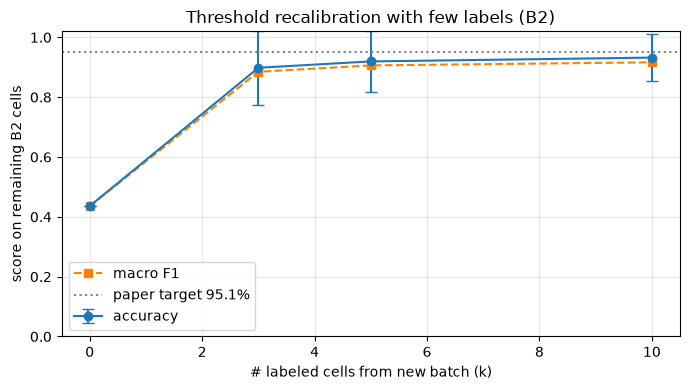

In [12]:
rc = o['recal']
display(rc.round(3))
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(rc['k'], rc['accuracy'], yerr=rc['accuracy_std'].fillna(0), marker='o', capsize=4, label='accuracy')
ax.plot(rc['k'], rc['macro_f1'], 's--', label='macro F1')
ax.axhline(TARGET_ACC, color='gray', ls=':', label='paper target 95.1%')
ax.set(xlabel='# labeled cells from new batch (k)', ylabel='score on remaining B2 cells', ylim=(0, 1.02),
       title='Threshold recalibration with few labels (B2)')
ax.legend(); plt.tight_layout(); plt.savefig(FIG / 'recalibration.png', dpi=120); plt.show()

- 라벨 3개만 있어도 정확도 0.44 → **0.90**, 10개면 **0.93** (원논문 목표 95.1% 근접)
- AUC 1.0 이었던 이유(순서는 맞음)와 일치 : 기준 위치만 옮기면 대부분 회복됨
- **이 결과는 B2 정답을 일부 사용한 것이므로 본 성능 표에는 넣지 않음** (운영 절차 제안용)

## 10. 모델 해석

In [13]:
coef = o['coef']
print('ElasticNet 계수 (표준화 피처 기준, 타깃 = log10 수명) :', coef.round(4).to_dict())
std = o['feat'][o['feat'].batch == 'B1']['w100_dQ_logvar'].std()
print(f"ΔQ 분산(log10)이 1 증가(분산 10배) → 수명 × {10 ** (coef.iloc[0] / std):.2f} 배")

ElasticNet 계수 (표준화 피처 기준, 타깃 = log10 수명) : {'w100_dQ_logvar': -0.0676}
ΔQ 분산(log10)이 1 증가(분산 10배) → 수명 × 0.67 배


- ΔQ 곡선의 분산이 10배 커지면 예측 수명이 약 0.67배로 줄어듦 → "방전 곡선 모양 변화가 클수록 수명이 짧다" 는 Day 1 해석과 같은 방향
- 피처가 하나라 운영자에게 설명하기 쉬움 : "초기 100사이클 동안 방전 곡선이 얼마나 변했는가"

## 11. ESS 도메인 해석

**이 모델을 실제 BESS 에 적용한다면**
- 설치 후 약 100사이클(수개월 운전) 시점에 셀/모듈별 ΔQ 분산을 계산 → 예측 수명이 짧은 셀 순으로 **점검·교체 우선순위**를 정함 (AUC 1.0 → 순위 활용에 강함)
- 단수명으로 판정된 모듈은 **피크 대응 부하 배분을 줄이고** 교체 예산을 앞당겨 편성 (교체 비용 = CAPEX 30~40%)
- 같은 lot 내 상대 비교(순위)는 바로 쓸 수 있고, 절대 수명(550 판정)은 아래 재보정 절차를 거쳐 사용

**한계와 실 배포에 필요한 것**
- **lot·조건이 바뀌면 절대 기준이 어긋남** (B2) → 새 lot 도입 시 셀 3~10개를 가속 수명 시험해 기준을 재보정하는 절차 필요
- 학습 데이터에 단수명 셀이 1개뿐 → 단수명 사례를 더 확보해야 판정 경계가 안정됨
- 실험실 조건(고정 온도·정전류 방전)과 실제 ESS 운전(부분 충방전, 온도 변동)이 다름 → 현장 데이터로 ΔQ 계산 방식 검증 필요
- 판정에 100사이클이 필요 → 제조 직후 스크리닝은 불가, **운전 초기 진단** 용도로 한정

## 12. Day 1 약속 이행 체크

| Day 1 보고서 항목 | 이행 | 결과 |
|---|---|---|
| ΔQ_100-10 분산 중심 최소 피처 | ✅ | B1 CV 로 core 확정 |
| 보조 후보(첨도·전환 시점) B1 CV 검토 | ✅ | 개선 없어 미채택 |
| log(수명) ElasticNet → 550 판정 | ✅ | 최종 모델 |
| 중도 종료 셀 회귀 제외, B1 으로만 스케일링, 550 고정 | ✅ | src/train.py |
| GroupKFold(충전 방식) / Hold-out(충전 방식 20%) | ✅ | 1 |
| 후보 5종 비교 | ✅ | 4 |
| B2 F1·Accuracy·Gap 3종 + AUC | ✅ | 2, 5 |
| B3 MAPE·순위 상관 중심 | ✅ | 2, 5 |
| 오류 분석 (B2 일반 셀 집중 여부) | ✅ | 6 — 오분류 전부 일반 셀 |
| B1 단독 선별 세트 비교 | ✅ | 7 — B1 CV 에서도 열세 |
| 5사이클 기준선 | ✅ | 8 |
| 재보정 운영 시나리오 (분리 보고) | ✅ | 9 |